<p style="align: center;"><img src="https://static.tildacdn.com/tild6636-3531-4239-b465-376364646465/Deep_Learning_School.png" width="400"></p>

# Глубокое обучение. Часть 2
# Домашнее задание по теме "Механизм внимания"

Это домашнее задание проходит в формате peer-review. Это означает, что его будут проверять ваши однокурсники. Поэтому пишите разборчивый код, добавляйте комментарии и пишите выводы после проделанной работы.

В этом задании вы будете решать задачу классификации математических задач по темам (многоклассовая классификация) с помощью Transformer.

В качестве датасета возьмем датасет математических задач по разным темам. Нам необходим следующий файл:

[Файл с классами](https://docs.google.com/spreadsheets/d/13YIbphbWc62sfa-bCh8MLQWKizaXbQK9/edit?usp=drive_link&ouid=104379615679964018037&rtpof=true&sd=true)

**Hint:** не перезаписывайте модели, которые вы получите на каждом из этапов этого дз. Они ещё понадобятся.

### Задание 1 (2 балла)

Напишите кастомный класс для модели трансформера для задачи классификации, использующей в качествке backbone какую-то из моделей huggingface.

Т.е. конструктор класса должен принимать на вход название модели и подгружать её из huggingface, а затем использовать в качестве backbone (достаточно возможности использовать в качестве backbone те модели, которые упомянуты в последующих пунктах)

In [1]:
import torch
import torch.nn as nn
from transformers import AutoModel, AutoConfig
from typing import Union

class TransformerClassificationModel(nn.Module):
    def __init__(self, base_transformer_model: Union[str, nn.Module], num_classes: int):
        super().__init__()
        if isinstance(base_transformer_model, str):
            self.config = AutoConfig.from_pretrained(base_transformer_model, output_attentions=True)
            self.backbone = AutoModel.from_pretrained(base_transformer_model, config=self.config)
        else:
            self.backbone = base_transformer_model
            self.config = self.backbone.config
            self.config.output_attentions = True

        hidden_size = self.config.hidden_size
        self.classifier = nn.Sequential(
            nn.Dropout(0.1),
            nn.Linear(hidden_size, num_classes)
        )

    def forward(self, input_ids, attention_mask=None, **kwargs):
        outputs = self.backbone(input_ids=input_ids, attention_mask=attention_mask, output_attentions=True, **kwargs)
        cls_token_state = outputs.last_hidden_state[:, 0, :]
        logits = self.classifier(cls_token_state)
        attentions = outputs.attentions if hasattr(outputs, 'attentions') and outputs.attentions else ()
        return {"logits": logits, "attentions": attentions}

### Задание 2 (1 балл)

Напишите функцию заморозки backbone у модели (если необходимо, возвращайте из функции модель)

In [2]:
def freeze_backbone_function(model: TransformerClassificationModel):
    for param in model.backbone.parameters():
        param.requires_grad = False
    return model

### Задание 3 (2 балла)

Напишите функцию, которая будет использована для тренировки (дообучения) трансформера (TransformerClassificationModel). Функция должна поддерживать обучение с замороженным и размороженным backbone.

In [3]:
import copy
import torch.optim as optim
from tqdm.auto import tqdm
import torch.nn as nn

def train_transformer(transformer_model, train_dataloader=None, epochs=3, freeze_backbone=True, device='cuda'):
    model = copy.deepcopy(transformer_model)
    model.to(device)
    
    if freeze_backbone:
        model = freeze_backbone_function(model)
        
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=2e-5)
    
    if train_dataloader is not None:
        for epoch in range(epochs):
            model.train()
            total_loss = 0
            for batch in tqdm(train_dataloader, desc=f"Training Epoch {epoch+1}"):
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels = batch['labels'].to(device)
                
                optimizer.zero_grad()
                outputs = model(input_ids, attention_mask=attention_mask)
                loss = criterion(outputs['logits'], labels)
                loss.backward()
                optimizer.step()
                
                total_loss += loss.item()
                
            print(f"Epoch {epoch+1} | Loss: {total_loss / len(train_dataloader):.3f}")
            
    return model

In [4]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import Dataset, DataLoader

# 1. Загрузка данных
csv_path = "data_problems_translated.xlsx - Sheet1.csv"
df = pd.read_csv(csv_path)
text_column_name = 'problem_text'
label_column_name = 'topic'

# 2. Кодирование меток 
label_encoder = LabelEncoder()
df['encoded_labels'] = label_encoder.fit_transform(df[label_column_name])
num_classes = len(label_encoder.classes_)
print(f"Количество классов: {num_classes}")

# 3. PyTorch Dataset
class MathProblemsDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=256):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length
        
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]
        
        encoding = self.tokenizer(
            text,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

def prepare_dataloader(dataframe, tokenizer, batch_size=16):
    dataset = MathProblemsDataset(
        texts=dataframe[text_column_name].values,
        labels=dataframe['encoded_labels'].values,
        tokenizer=tokenizer
    )
    return DataLoader(dataset, batch_size=batch_size, shuffle=True)

Количество классов: 7


### Задание 4 (1 балл)

Проверьте вашу функцию из предыдущего пункта, дообучив двумя способами
*cointegrated/rubert-tiny2* из huggingface.

In [5]:
from transformers import AutoTokenizer

model_name_4 = "cointegrated/rubert-tiny2"
tokenizer_4 = AutoTokenizer.from_pretrained(model_name_4)
train_dataloader_4 = prepare_dataloader(df, tokenizer_4)

rubert_tiny_transformer_model = TransformerClassificationModel(model_name_4, num_classes=num_classes)

print("Обучение с замороженным backbone (rubert-tiny2)...")
rubert_tiny_finetuned_with_freezed_backbone = train_transformer(
    rubert_tiny_transformer_model, 
    train_dataloader=train_dataloader_4, 
    epochs=3, 
    freeze_backbone=True
)

print("Обучение с размороженным backbone (rubert-tiny2)...")
rubert_tiny_full_finetuned = train_transformer(
    rubert_tiny_transformer_model, 
    train_dataloader=train_dataloader_4, 
    epochs=3, 
    freeze_backbone=False
)

Loading weights:   0%|          | 0/55 [00:00<?, ?it/s]

BertModel LOAD REPORT from: cointegrated/rubert-tiny2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Обучение с замороженным backbone (rubert-tiny2)...


Training Epoch 1:   0%|          | 0/330 [00:00<?, ?it/s]

Epoch 1 | Loss: 1.884


...

Epoch 1 | Loss: 1.343


Training Epoch 2:   0%|          | 0/330 [00:00<?, ?it/s]

Epoch 2 | Loss: 1.042


Training Epoch 3:   0%|          | 0/330 [00:00<?, ?it/s]

Epoch 3 | Loss: 0.942


### Задание 5 (1 балл)

Обучите *tbs17/MathBert* (с замороженным backbone и без заморозки), проанализируйте результаты. Сравните скоры с первым заданием. Получилось лучше или нет? Почему?

In [6]:
model_name_5 = "tbs17/MathBert"
tokenizer_5 = AutoTokenizer.from_pretrained(model_name_5)
train_dataloader_5 = prepare_dataloader(df, tokenizer_5)

mathbert_transformer_model = TransformerClassificationModel(model_name_5, num_classes=num_classes)

print("Обучение с замороженным backbone (MathBert)...")
mathbert_finetuned_with_freezed_backbone = train_transformer(
    mathbert_transformer_model, 
    train_dataloader=train_dataloader_5, 
    epochs=3, 
    freeze_backbone=True
)

print("Обучение с размороженным backbone (MathBert)...")
mathbert_full_finetuned = train_transformer(
    mathbert_transformer_model, 
    train_dataloader=train_dataloader_5, 
    epochs=3, 
    freeze_backbone=False
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: tbs17/MathBert
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Обучение с замороженным backbone (MathBert)...


Training Epoch 1:   0%|          | 0/330 [00:00<?, ?it/s]

Epoch 1 | Loss: 1.750


...

Epoch 1 | Loss: 1.141


Training Epoch 2:   0%|          | 0/330 [00:00<?, ?it/s]

Epoch 2 | Loss: 0.867


Training Epoch 3:   0%|          | 0/330 [00:00<?, ?it/s]

Epoch 3 | Loss: 0.697


### Задание 6 (1 балл)

Напишите функцию для отрисовки карт внимания первого слоя для моделей из задания

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
import torch
from typing import List

def draw_first_layer_attention_maps(attention_head_ids: List[int], text: str, model: TransformerClassificationModel, tokenizer):
    model.eval()
    inputs = tokenizer(text, return_tensors='pt').to(next(model.parameters()).device)
    
    with torch.no_grad():
        outputs = model(**inputs)
        
    attentions = outputs.get('attentions', [])
    if not attentions:
        print("Внимание (attentions) не вернулось из модели! Проверьте output_attentions=True")
        return
        
    first_layer_attention = attentions[0].squeeze(0).cpu().numpy()
    
    tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0].tolist())
    
    for head_id in attention_head_ids:
        plt.figure(figsize=(8, 8))
        attn_matrix = first_layer_attention[head_id]
        
        sns.heatmap(attn_matrix, xticklabels=tokens, yticklabels=tokens, cmap='Blues')
        plt.title(f'Attention Head {head_id} (Layer 1)')
        plt.xlabel('Keys')
        plt.ylabel('Queries')
        plt.show()

### Задание 7 (1 балл)

Проведите инференс для всех моделей **ДО ДООБУЧЕНИЯ** на 2-3 текстах из датасета. Посмотрите на головы Attention первого слоя в каждой модели на выбранных текстах (отрисуйте их отдельно).

Попробуйте их проинтерпретировать. Какие связи улавливают карты внимания? (если в модели много голов Attention, то проинтерпретируйте наиболее интересные)

========== Карты внимания rubert-tiny2 ДО дообучения ==========

Текст: To prove that the sum of the numbers of the exact square cannot be equal to 5....


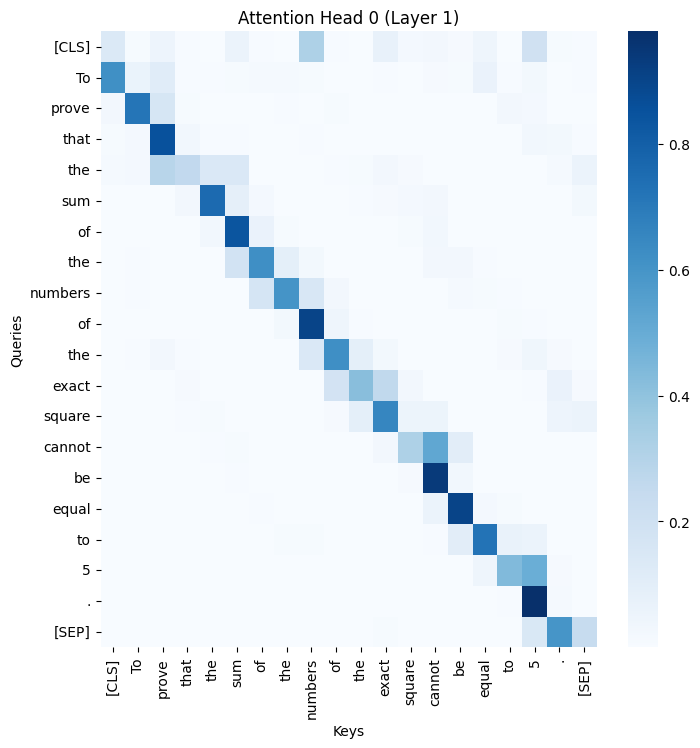

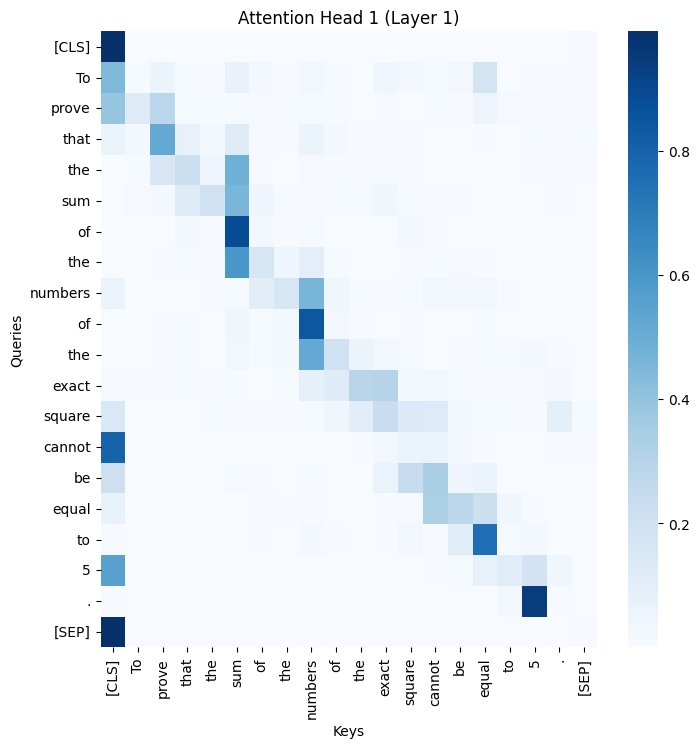

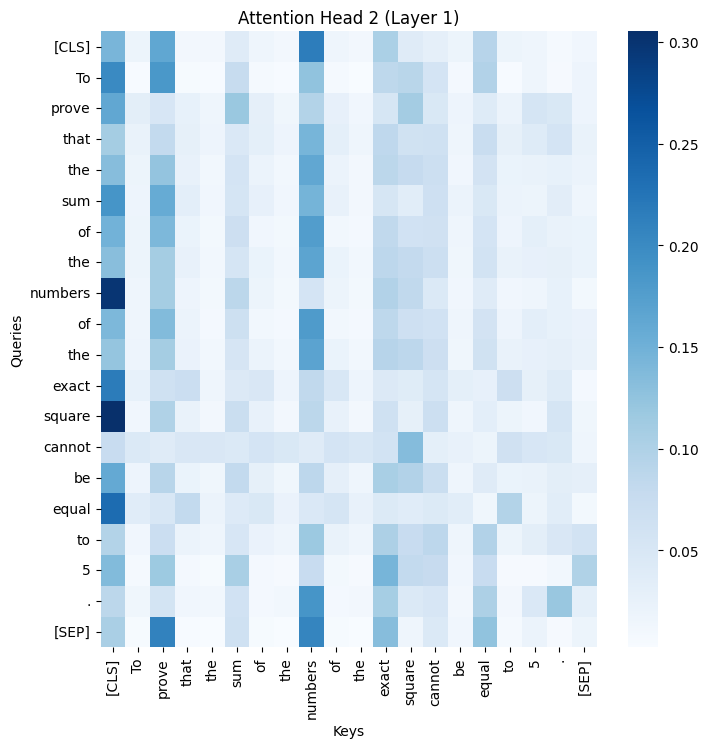


Текст: ( b) Will the statement of the previous challenge remain true if Petia and Wasa originally planned f...


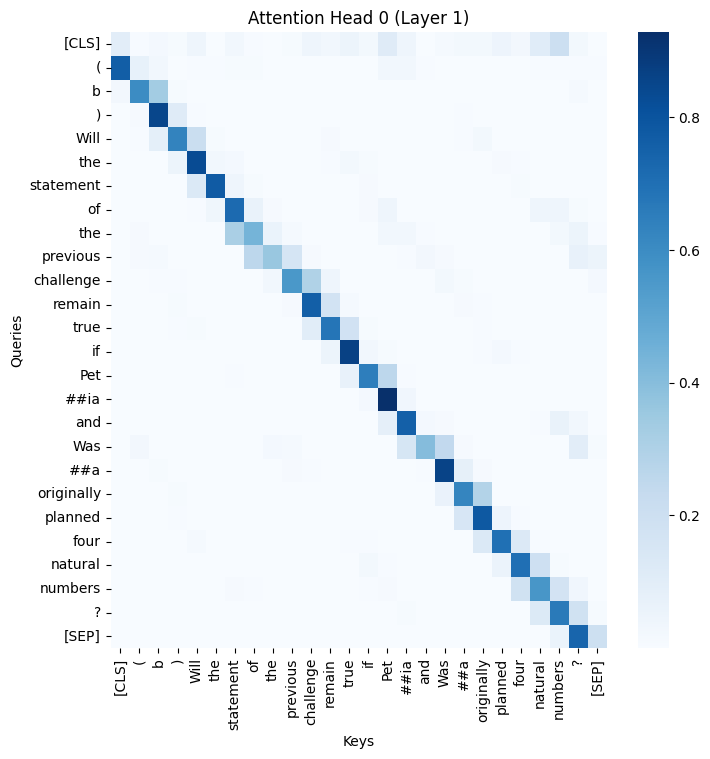

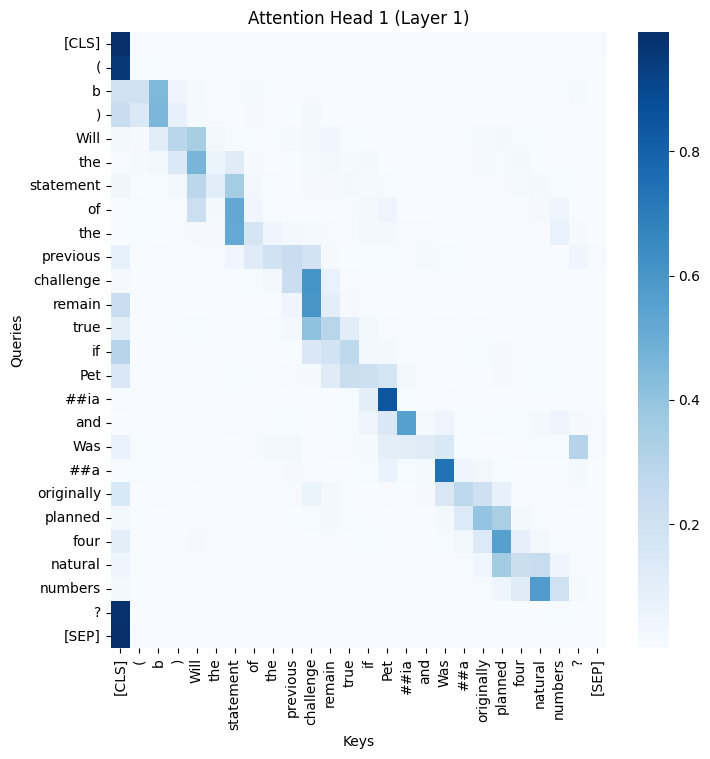

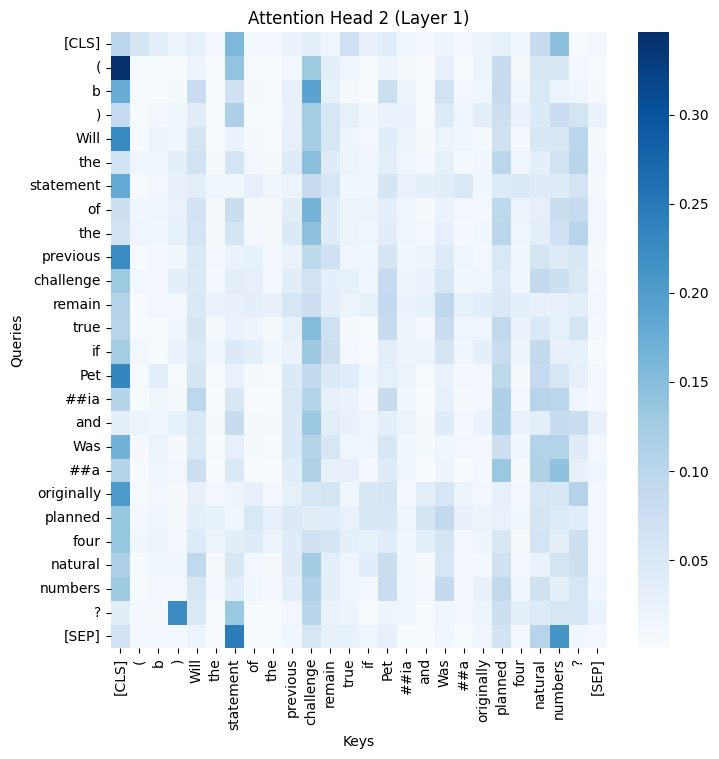


========== Карты внимания MathBert ДО дообучения ==========

Текст: To prove that the sum of the numbers of the exact square cannot be equal to 5....


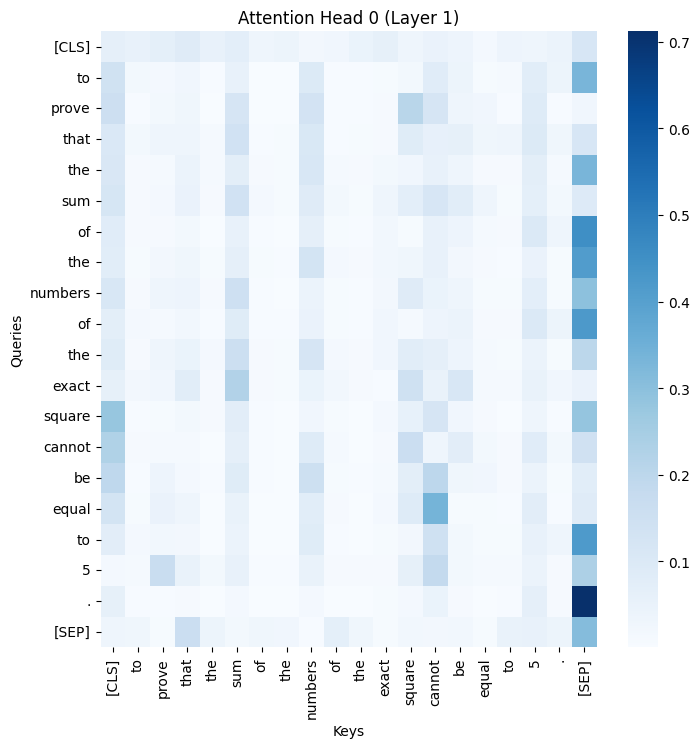

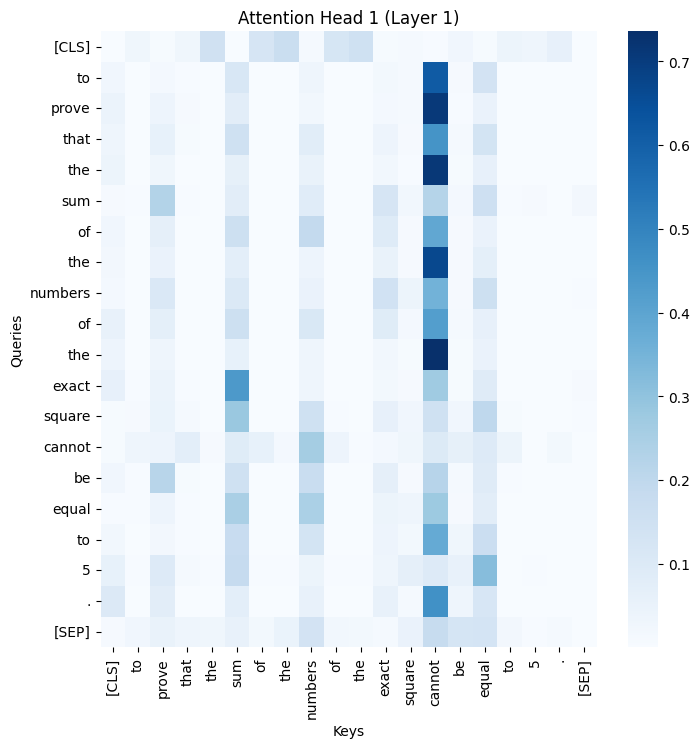

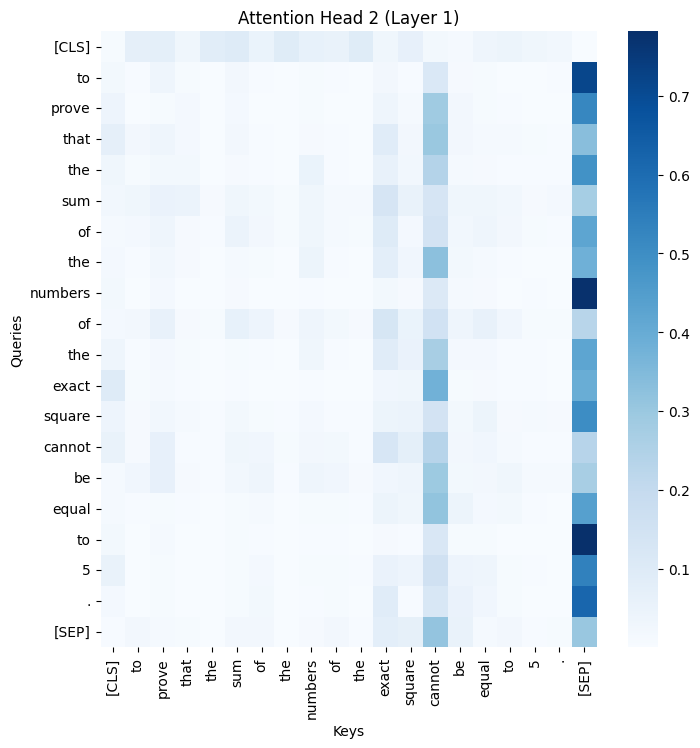


Текст: ( b) Will the statement of the previous challenge remain true if Petia and Wasa originally planned f...


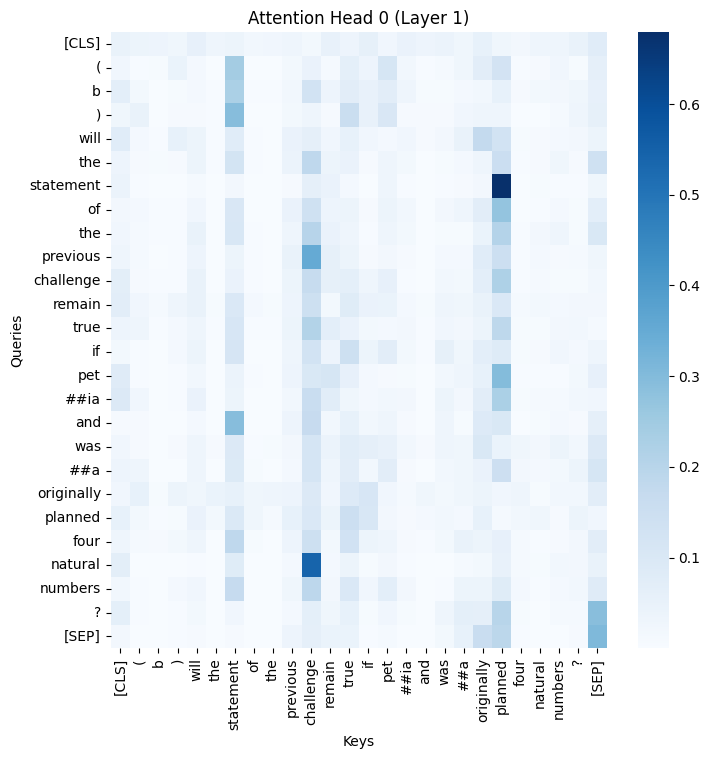

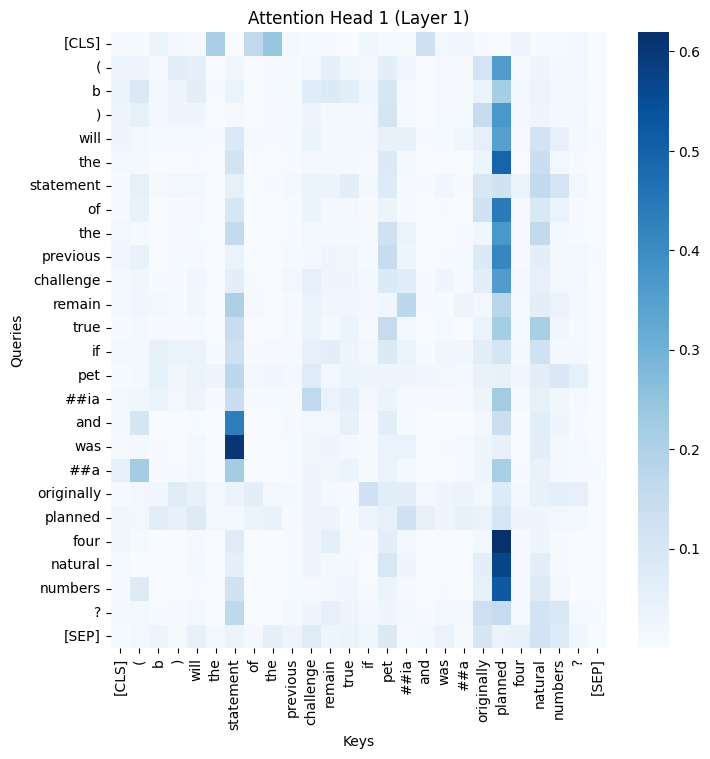

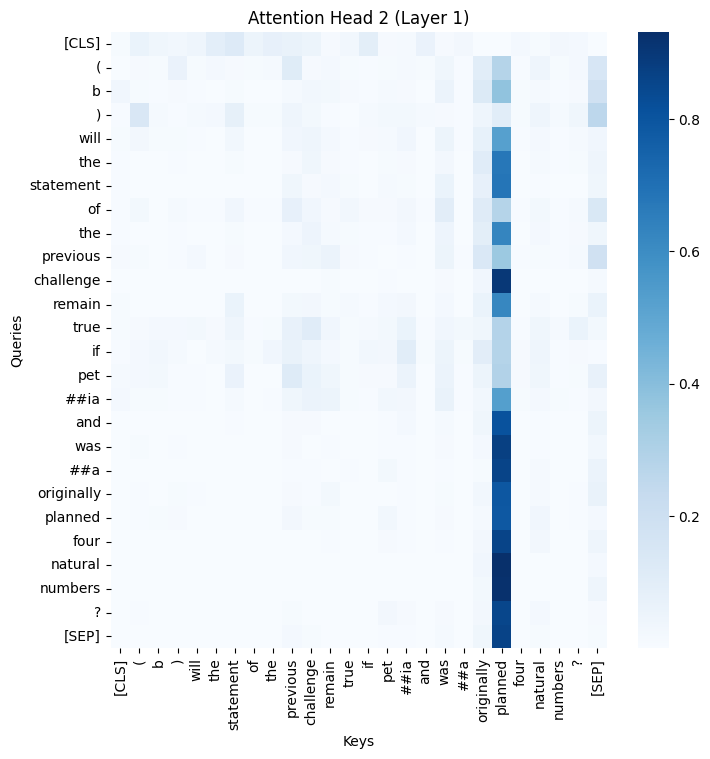

In [ ]:
sample_texts = df[text_column_name].dropna().values[:2].tolist()

heads_to_draw = [0, 1, 2]

print("========== Карты внимания rubert-tiny2 ДО дообучения ==========")
for text in sample_texts:
    print(f"\nТекст: {text[:100]}...")
    draw_first_layer_attention_maps(heads_to_draw, text, rubert_tiny_transformer_model, tokenizer_4)

print("\n========== Карты внимания MathBert ДО дообучения ==========")
for text in sample_texts:
    print(f"\nТекст: {text[:100]}...")
    draw_first_layer_attention_maps(heads_to_draw, text, mathbert_transformer_model, tokenizer_5)

### Интерпретация карт внимания (до дообучения):

#### Головы `rubert-tiny2`
* **Голова, смотрящая на предыдущий токен (head 0):** каждый токен-запрос обращает максимальное внимание на токен, стоящий непосредственно перед ним. В матрице выглядит как диагональная линия, смещенная на один шаг влево

* **Голова синтаксической связи (head 1):** первый запрос of (ось Y) имеет максимальный вес внимания к ключу sum (ось X). Второй запрос of смотрит на numbers. Голова научилась связывать предлоги с существительными, к которым они относятся. Также видно, что токены [CLS] и [SEP] обращают внимание на [CLS] — это стандартный паттерн для аккумуляции контекста всего предложения

* **Глобальные смысловые якоря (head 2):** Здесь мы видим четкие вертикальные полосы. Это означает, что независимо от того, какой токен является запросом (ось Y), он всегда отдает часть своего внимания определенным ключам (ось X). В данном случае "магнитами" для внимания выступают токены [CLS], prove, sum, numbers и exact. Эта голова работает как фильтр ключевых слов, заставляя каждый токен в предложении "помнить" о главных смысловых узлах текста

#### Головы `MathBert` 
Здесь у всех голов прослеживается общий паттерн — все они имеют строго вертикальныелиние на определнных словах. Этот эффект аналогичен голове 2 модели __rubert-tiny2__ (глобальные смысловые якоря). Давайте подробнее проанализируем каждую голову
* **Голова 0**: Внимание довольно размытое, но все равно тяготеет к вертикалям. В первом тексте выделяются cannot и [SEP], во втором — statement, challenge и planned

* **Голова 1**: Очень сильные и контрастные вертикальные линии.
В первом тексте (про квадраты) абсолютным магнитом для внимания стало слово cannot, а также sum, equal и numbers
Во втором тексте (про Петю и Васю) почти все слова смотрят на planned и statement.

* **Голова 2**: Картина аналогична первой голове. В первом тексте сильнейший фокус на [SEP] и cannot, во втором — массивный пик на planned.

Отличия между `rubert-tiny2` и `MathBert`: `rubert-tiny2` ориентирован больше на общую русскую/многоязычную семантику и поиск локальных связей, тогда как исходный `MathBert` может немного больше активироваться на цифрах и математических терминах или формулах

### Задание 8 (1 балл)

Сделайте то же самое для дообученных моделей. Изменились ли карты внимания и связи, которые они улавливают? Почему?

========== Карты внимания rubert-tiny2 ПОСЛЕ дообучения (размороженный backbone) ==========

Текст: To prove that the sum of the numbers of the exact square cannot be equal to 5....


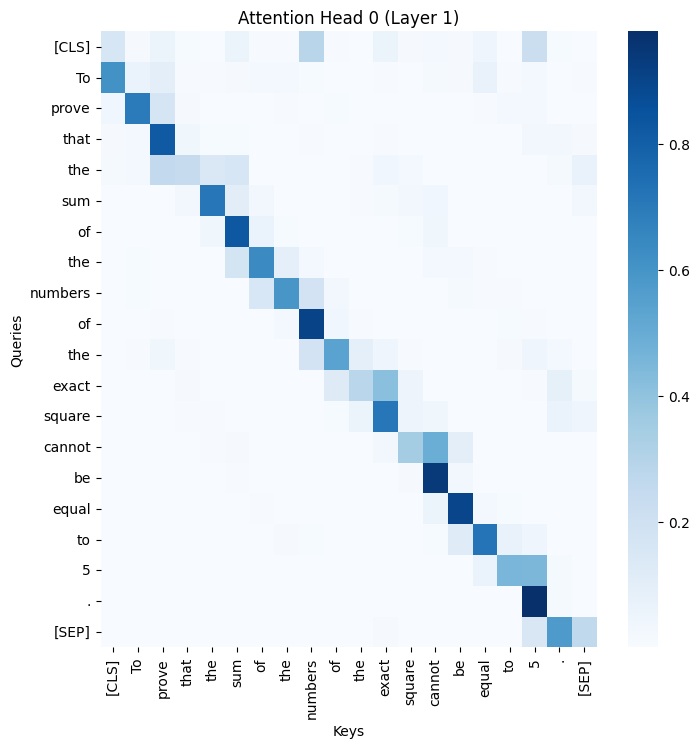

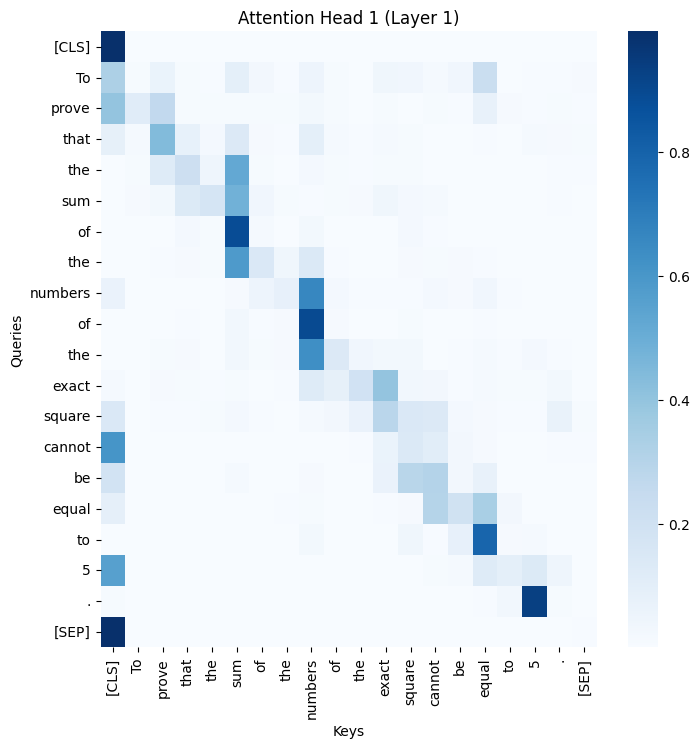

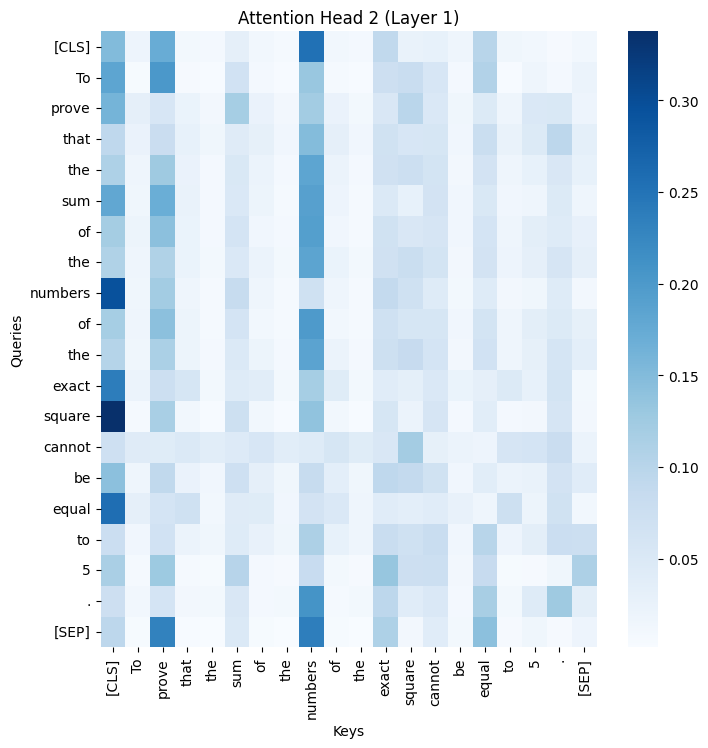


Текст: ( b) Will the statement of the previous challenge remain true if Petia and Wasa originally planned f...


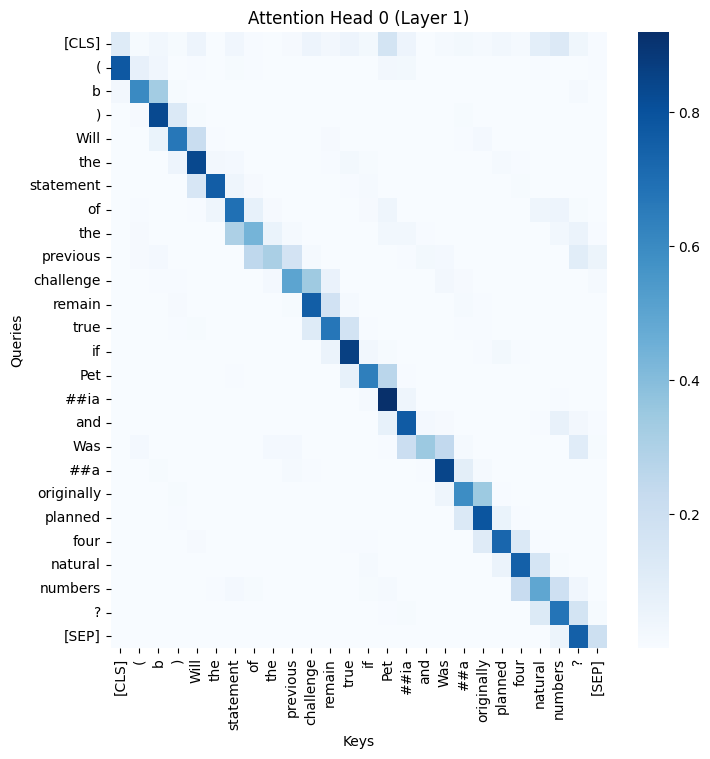

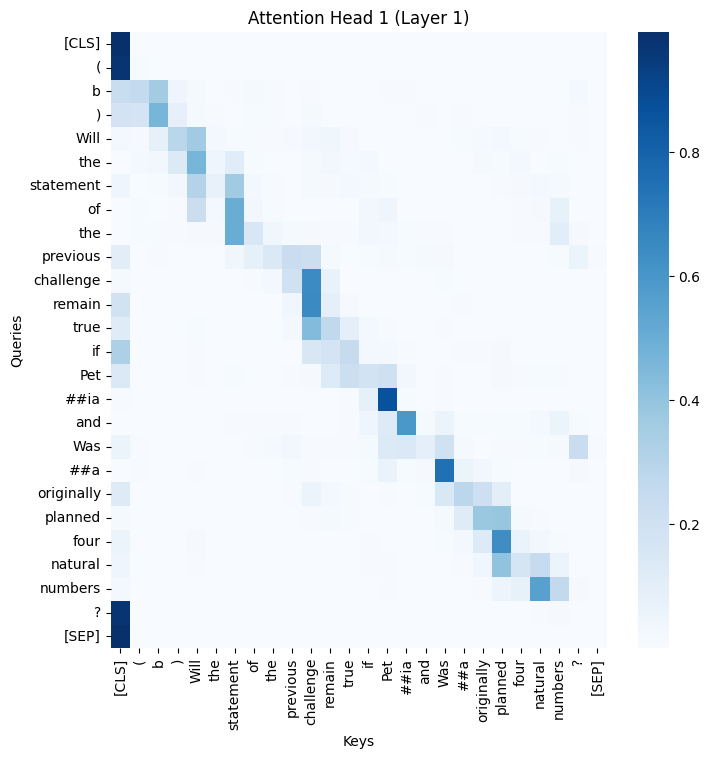

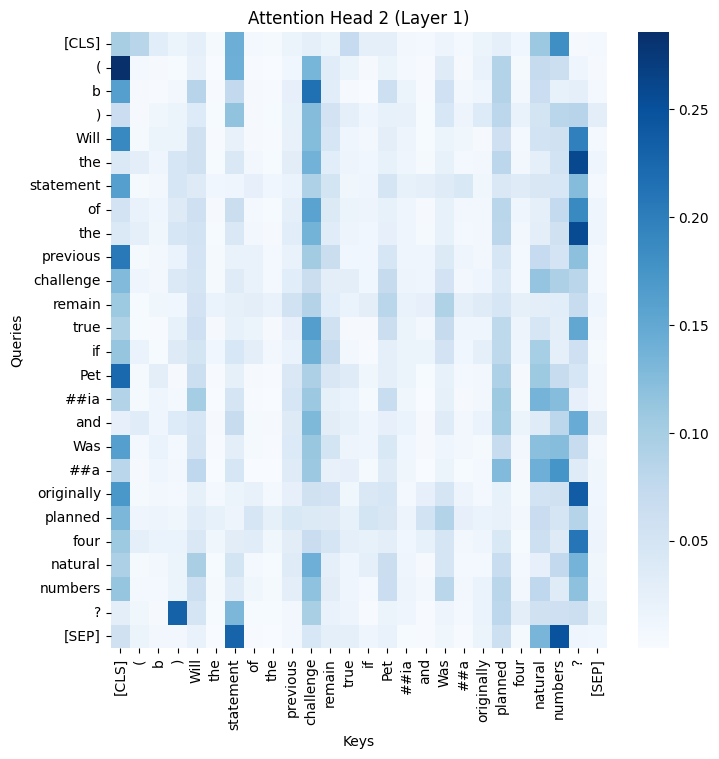


========== Карты внимания MathBert ПОСЛЕ дообучения (размороженный backbone) ==========

Текст: To prove that the sum of the numbers of the exact square cannot be equal to 5....


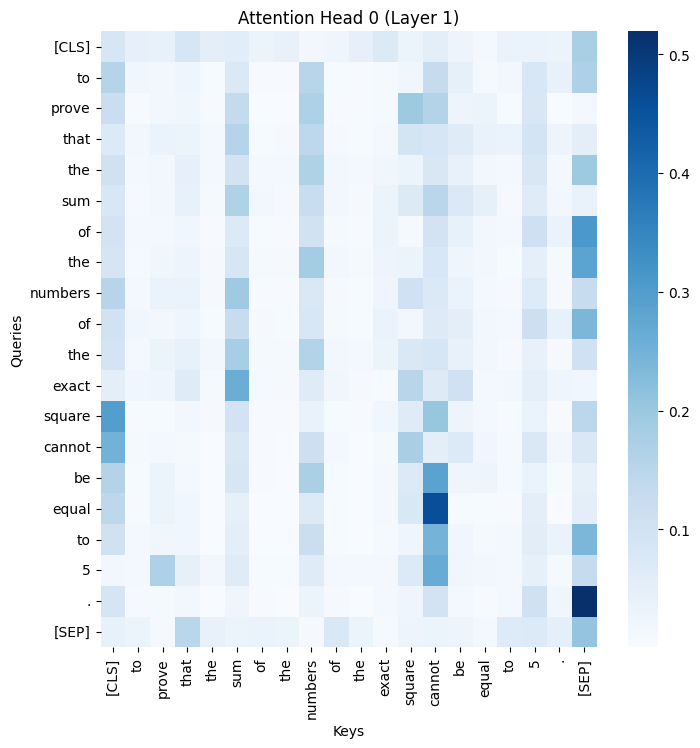

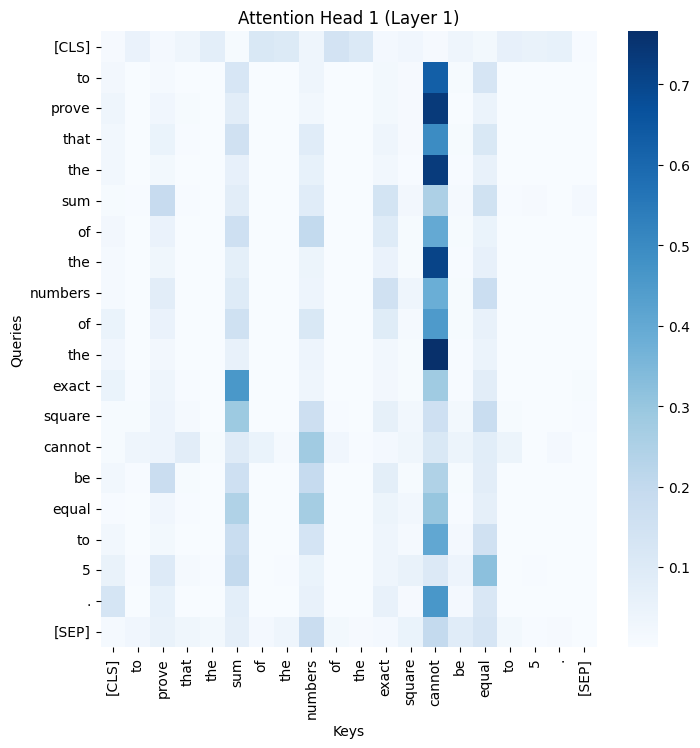

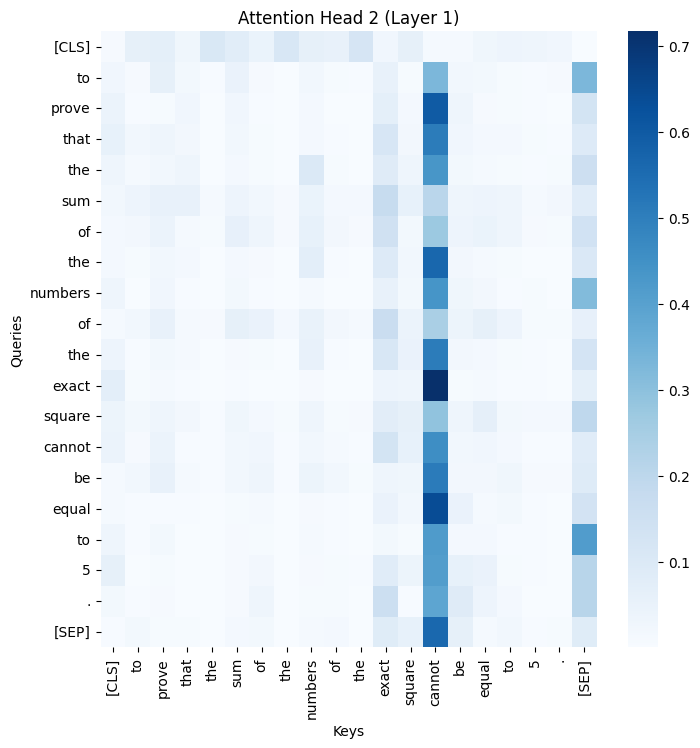


Текст: ( b) Will the statement of the previous challenge remain true if Petia and Wasa originally planned f...


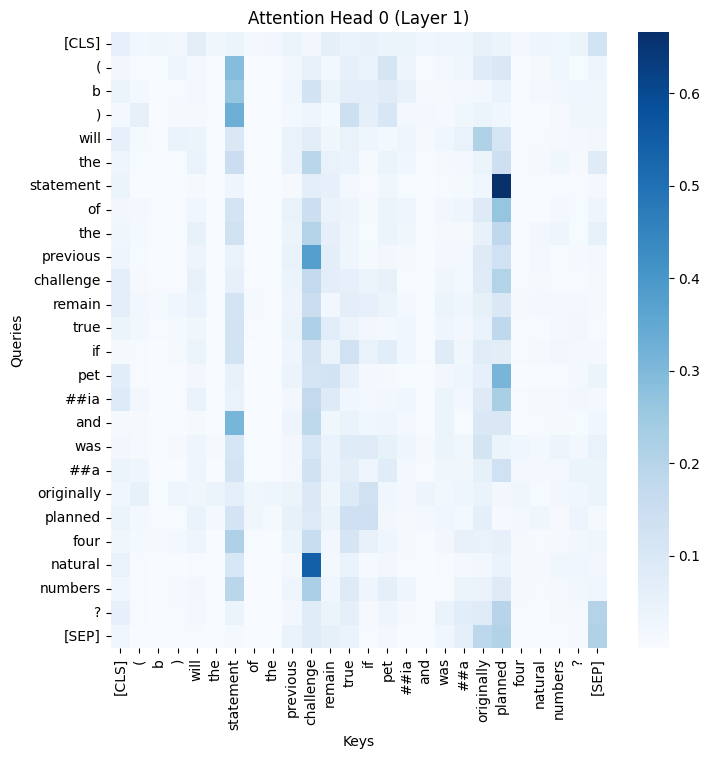

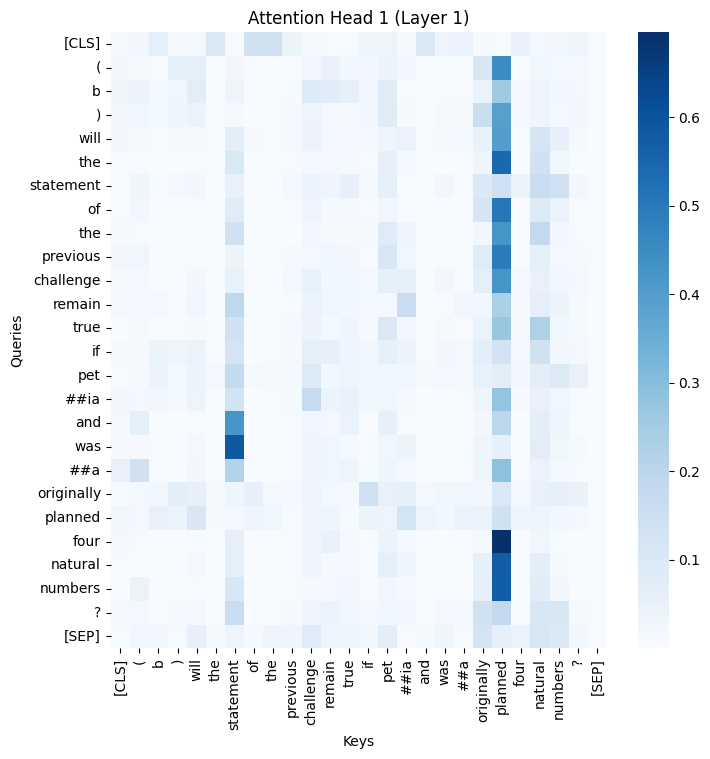

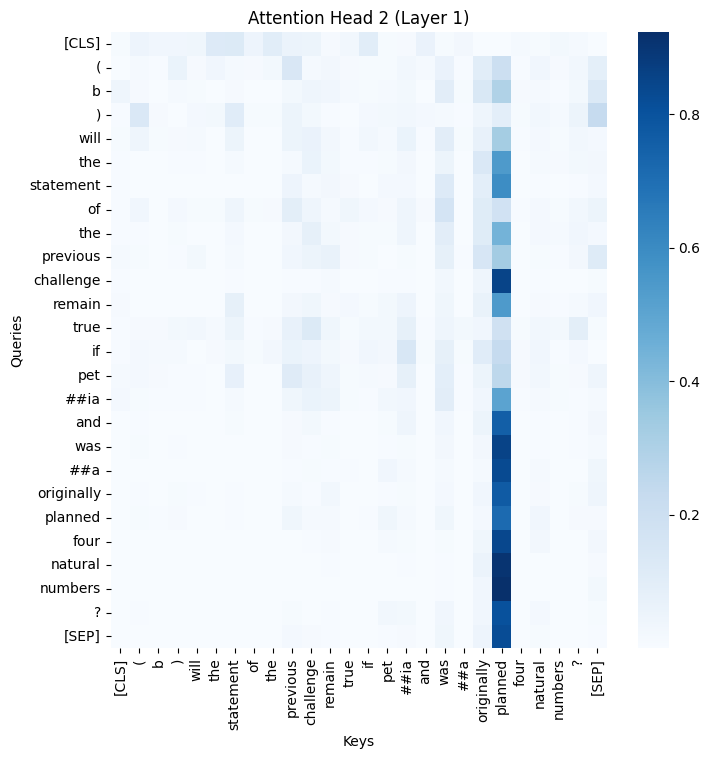

In [ ]:
print("========== Карты внимания rubert-tiny2 ПОСЛЕ дообучения (размороженный backbone) ==========")
for text in sample_texts:
    print(f"\nТекст: {text[:100]}...")
    draw_first_layer_attention_maps(heads_to_draw, text, rubert_tiny_full_finetuned, tokenizer_4)

print("\n========== Карты внимания MathBert ПОСЛЕ дообучения (размороженный backbone) ==========")
for text in sample_texts:
    print(f"\nТекст: {text[:100]}...")
    draw_first_layer_attention_maps(heads_to_draw, text, mathbert_full_finetuned, tokenizer_5)

### Интерпретация карт внимания (после дообучения):

#### Головы `rubert-tiny2`
* **Голова, смотрящая на предыдущий токен (head 0):** каждый токен-запрос обращает максимальное внимание на токен, стоящий непосредственно перед ним. В матрице выглядит как диагональная линия, смещенная на один шаг влево (аналогично исходной модели)

* **Голова синтаксической связи (head 1):** первый запрос of (ось Y) имеет максимальный вес внимания к ключу sum (ось X). Второй запрос of смотрит на numbers. Голова научилась связывать предлоги с существительными, к которым они относятся. Также видно, что токены [CLS] и [SEP] обращают внимание на [CLS] — это стандартный паттерн для аккумуляции контекста всего предложения (аналогично исходной модели)

* **Глобальные смысловые якоря (head 2):** Здесь мы видим четкие вертикальные полосы. Это означает, что независимо от того, какой токен является запросом (ось Y), он всегда отдает часть своего внимания определенным ключам (ось X). В данном случае "магнитами" для внимания выступают токены [CLS], prove, sum, numbers и exact. Эта голова работает как фильтр ключевых слов, заставляя каждый токен в предложении "помнить" о главных смысловых узлах текста. Главное отличие от исходной модели — модель начала уделять больше внимания эмоциональным знакам преинания (в примере вопросительный знак)

#### Головы `MathBert`
**Головы остались почти такими же, но** немного сменились якоря, например если раньше голова 2 на первом предложении больше внимания уделяла токену [SEP], то после дообучения внимание переключилось на cannot